AutoEncoder is made of an encoder and decoder

In [67]:
from tensorflow.keras.layers import Dense, Input, LSTM, RepeatVector, TimeDistributed
from tensorflow.keras.models import Model

from tensorflow.keras.datasets import fashion_mnist

In [68]:
data = fashion_mnist.load_data()
(trainFeatures, trainTarget), (testFeatures, testTarget) = data

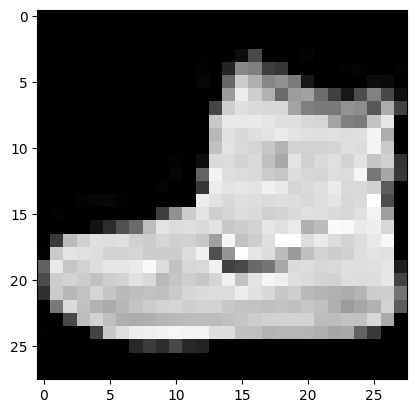

In [69]:
import matplotlib.pyplot as plt

plt.imshow(trainFeatures[0], cmap='gray')

In [70]:
trainFeaturesNew = trainFeatures / 255 # normalisation
testFeaturesNew = testFeatures / 255

In [71]:
testFeaturesNew[0].shape

(28, 28)

In [72]:
# building layers for encoder

inputLayer = Input(shape=(28, 28)) # 784 (28*28)
lstmLayer = LSTM(128, activation='relu', return_state=True)(inputLayer) # for forgetting unecessary data (narrowed down from 784 to 128)

hiddenState = lstmLayer[1]

encoder = Model(inputLayer, hiddenState) # encoder to compress the image to something simple

In [73]:
# building layers for decoder

inputLayerD = Input(shape=(128, )) # taking input from encoder, must be the shape of the encoder's output
repeatVectorLayer = RepeatVector(28)(inputLayerD) # repreat 28 times - 28 rows
lstmLayer = LSTM(128, activation='relu', return_sequences=True)(repeatVectorLayer)
dense = TimeDistributed(Dense(28, activation='sigmoid'))(lstmLayer)

decoder = Model(inputLayerD, dense) # decoder to rebuild the image from simplified data

In [ ]:
trainFeaturesNoise # research how to add noise to images

In [75]:
autoEncoder = Model(inputLayer, decoder(encoder(inputLayer)))
autoEncoder.compile(optimizer='adam', loss='binary_crossentropy')
autoEncoder.fit(trainFeaturesNew, epochs=10, batch_size=10)

Epoch 1/10


ValueError: None values not supported.